In [1]:
!pip install datasets
!pip install transformers
!pip install evaluate
!pip install seqeval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=40e52103b6eaa55aab52f8aada5b59684f094984edd0361136a85f3764e4934e
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


# indobenchmark/indobert-base-p1

## load model

In [2]:
from transformers import BertTokenizer, AutoModel

tokenizer = BertTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

## load dataset

In [3]:
label_list = ["O", "B-TOXIC", "I-TOXIC"]
label2id = {"O": 0, "B-TOXIC": 1, "I-TOXIC": 2}
id2label = {0: "O", 1: "B-TOXIC", 2: "I-TOXIC"}

In [4]:
import json

with open("/kaggle/input/datasets/alikakaylanisha/toxic-span-id-gamechat-4-0/ALL_IOB_1.0.jsonl") as user_file:
  file_contents = user_file.read()


In [5]:
from datasets import load_dataset
file_path = "/kaggle/input/datasets/alikakaylanisha/toxic-span-id-gamechat-4-0/ALL_IOB__encoded_1.0.jsonl"
dataset = load_dataset("json", data_files=file_path)

Generating train split: 0 examples [00:00, ? examples/s]

In [6]:
dataset['train']

Dataset({
    features: ['tokens', 'ner_tags'],
    num_rows: 5385
})

In [7]:
from datasets import DatasetDict

dataset_split = dataset["train"].train_test_split(test_size=0.2, seed=42)

print(dataset_split)

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 4308
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 1077
    })
})


In [8]:
train_dataset = dataset_split["train"]
test_val_dataset = dataset_split["test"]

In [9]:
test_val_split = test_val_dataset.train_test_split(test_size= 0.5, seed=42)
test_dataset = test_val_split["train"]
val_dataset = test_val_split["test"]

In [10]:
test_dataset

Dataset({
    features: ['tokens', 'ner_tags'],
    num_rows: 538
})

In [11]:
val_dataset

Dataset({
    features: ['tokens', 'ner_tags'],
    num_rows: 539
})

In [12]:
train_dataset

Dataset({
    features: ['tokens', 'ner_tags'],
    num_rows: 4308
})

In [13]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True, return_offsets_mapping=True)

    labels = []
    #addition
    all_word_ids = []
    for i, label in enumerate(examples[f"ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)  # Map tokens to their respective word.
        previous_word_idx = None
        label_ids = []
        
        for word_idx in word_ids:  # Set the special tokens to -100.
            if word_idx is None:
                label_ids.append(-100)
                
            elif word_idx != previous_word_idx:  # Only label the first token of a given word.
                label_ids.append(label[word_idx])
                
            else:
                label_ids.append(-100)
                
            previous_word_idx = word_idx
            
        labels.append(label_ids)
        
        # SAVE word_ids (addition)
        all_word_ids.append([
            -1 if w is None else w
            for w in word_ids
        ])
        
    tokenized_inputs["word_ids"] = all_word_ids
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

In [14]:
tokenized_dataset_train = train_dataset.map(tokenize_and_align_labels, batched=True)
tokenized_dataset_val = val_dataset.map(tokenize_and_align_labels, batched=True)
tokenized_dataset_test = test_dataset.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/4308 [00:00<?, ? examples/s]

Map:   0%|          | 0/539 [00:00<?, ? examples/s]

Map:   0%|          | 0/538 [00:00<?, ? examples/s]

In [15]:
tokenized_dataset_train

Dataset({
    features: ['tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'word_ids', 'labels'],
    num_rows: 4308
})

In [16]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

## evaluate

In [17]:
import evaluate

seqeval = evaluate.load("seqeval")

In [18]:
import numpy as np


def compute_metrics_seqeval(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"]
    }

In [19]:
def compute_all_metrics(p):
    results = {}
    results.update(compute_metrics_seqeval(p))

    return results

## model loading and training

In [20]:
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer, EarlyStoppingCallback

model = AutoModelForTokenClassification.from_pretrained(
    "indobenchmark/indobert-base-p1", num_labels=3, id2label=id2label, label2id=label2id
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

In [21]:
training_args = TrainingArguments(
    output_dir="/kaggle/working/indobert-base_p1_toxic_span",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps= 10,

)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset_train,
    eval_dataset=tokenized_dataset_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_all_metrics,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.351904,0.318537,0.557692,0.633880,0.593350
2,0.286591,0.300158,0.598485,0.647541,0.622047


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=270, training_loss=0.37668509306731046, metrics={'train_runtime': 91.9497, 'train_samples_per_second': 93.703, 'train_steps_per_second': 2.936, 'total_flos': 320660971326072.0, 'train_loss': 0.37668509306731046, 'epoch': 2.0})

## logging loss

In [22]:
logs = trainer.state.log_history

In [23]:
train_logs = [x for x in logs if "loss" in x and "eval_loss" not in x]

In [24]:
eval_logs = [x for x in logs if "eval_loss" in x]

In [25]:
for log in train_logs:
    print(log["epoch"], log["loss"])

0.07407407407407407 1.031464195251465
0.14814814814814814 0.6481363296508789
0.2222222222222222 0.4834958553314209
0.2962962962962963 0.4537285327911377
0.37037037037037035 0.4946632385253906
0.4444444444444444 0.5307639122009278
0.5185185185185185 0.4313676834106445
0.5925925925925926 0.3795409917831421
0.6666666666666666 0.483585262298584
0.7407407407407407 0.37044329643249513
0.8148148148148148 0.35669312477111814
0.8888888888888888 0.41065683364868166
0.9629629629629629 0.3519038915634155
1.037037037037037 0.3069900035858154
1.1111111111111112 0.27833266258239747
1.1851851851851851 0.27872662544250487
1.2592592592592593 0.3075063705444336
1.3333333333333333 0.27317419052124026
1.4074074074074074 0.2633042335510254
1.4814814814814814 0.26226646900177003
1.5555555555555556 0.2292114019393921
1.6296296296296298 0.23658530712127684
1.7037037037037037 0.21094205379486083
1.7777777777777777 0.34663002490997313
1.8518518518518519 0.2324249267578125
1.925925925925926 0.2313692092895508
2.0

In [26]:
for log in eval_logs:
    print(log["epoch"], log["eval_loss"])

1.0 0.31853705644607544
2.0 0.3001583218574524


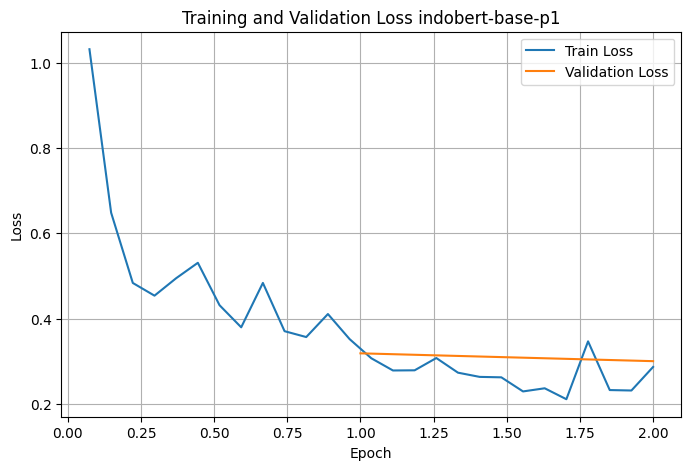

In [27]:
import matplotlib.pyplot as plt

train_epochs = [x["epoch"] for x in train_logs] # Epochs/step logs
train_loss = [x["loss"] for x in train_logs]

eval_epochs = [x["epoch"] for x in eval_logs]
eval_loss = [x["eval_loss"] for x in eval_logs]

# Plot
plt.figure(figsize=(8,5))

plt.plot(train_epochs, train_loss, label="Train Loss")
plt.plot(eval_epochs, eval_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss indobert-base-p1")

plt.legend()
plt.grid(True)

plt.show()

## Testing

In [28]:
SAVE_PATH = "/kaggle/working/indobert-base_p1_toxic_span"
trainer.save_model(SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [29]:
tokenized_dataset_test[0]

{'tokens': ['bencong', 'rombengmenjijikangay', 'jg'],
 'ner_tags': [1, 2, 0],
 'input_ids': [2,
  358,
  27921,
  3610,
  1771,
  5067,
  2455,
  11084,
  24587,
  138,
  6162,
  3],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'offset_mapping': [[0, 0],
  [0, 3],
  [3, 7],
  [0, 3],
  [3, 6],
  [6, 8],
  [8, 11],
  [11, 14],
  [14, 18],
  [18, 20],
  [0, 2],
  [0, 0]],
 'word_ids': [-1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, -1],
 'labels': [-100, 1, -100, 2, -100, -100, -100, -100, -100, -100, 0, -100]}

In [30]:
output = trainer.predict(tokenized_dataset_test)

predictions = output.predictions
labels = output.label_ids
pred_ids = np.argmax(predictions, axis=2)


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [31]:
output.metrics

{'test_loss': 0.3109564781188965,
 'test_precision': 0.6040100250626567,
 'test_recall': 0.6342105263157894,
 'test_f1': 0.6187419768934531,
 'test_runtime': 2.1388,
 'test_samples_per_second': 251.538,
 'test_steps_per_second': 7.948}

In [32]:
predictions.shape

(538, 166, 3)

### token level analysis

In [33]:
from sklearn.metrics import classification_report

def token_analysis(pred_ids, labels, id2label):
    y_true = [] # 1d flatten array to fit sklearn's classification report requirements
    y_pred = []

    # If gold/g is -100(padding/not the first subword token in a word) it is ignored since trainer predict also uses datacollator(pads for batch prediction)
    for pred_seq, gold_seq in zip(pred_ids, labels):
        for p, g in zip(pred_seq, gold_seq):
            if g == -100:
                continue  # ignore subwords

            y_true.append(id2label[g])
            y_pred.append(id2label[p])
    print(classification_report(y_true, y_pred, digits=4))

In [34]:
token_analysis(pred_ids, labels, id2label)

              precision    recall  f1-score   support

     B-TOXIC     0.7684    0.7421    0.7550       380
     I-TOXIC     0.6654    0.5987    0.6303       299
           O     0.9702    0.9777    0.9739      5559

    accuracy                         0.9452      6238
   macro avg     0.8013    0.7728    0.7864      6238
weighted avg     0.9433    0.9452    0.9441      6238



In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def token_confusion_matrix(pred_ids, labels, id2label):

    y_true = []
    y_pred = []

    # Flatten predictions
    for pred_seq, gold_seq in zip(pred_ids, labels):

        for p, g in zip(pred_seq, gold_seq):

            # ignore subwords
            if g == -100:
                continue

            y_true.append(id2label[g])
            y_pred.append(id2label[p])

    # Label order
    label_names = list(id2label.values())

    # Create confusion matrix
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=label_names
    )

    # Plot
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_names
    )

    fig, ax = plt.subplots(figsize=(8,8))
    disp.plot(ax=ax, cmap="Blues")

    plt.xticks(rotation=45)
    plt.title("Token-Level Confusion Matrix indobert-base-p1")
    plt.show()

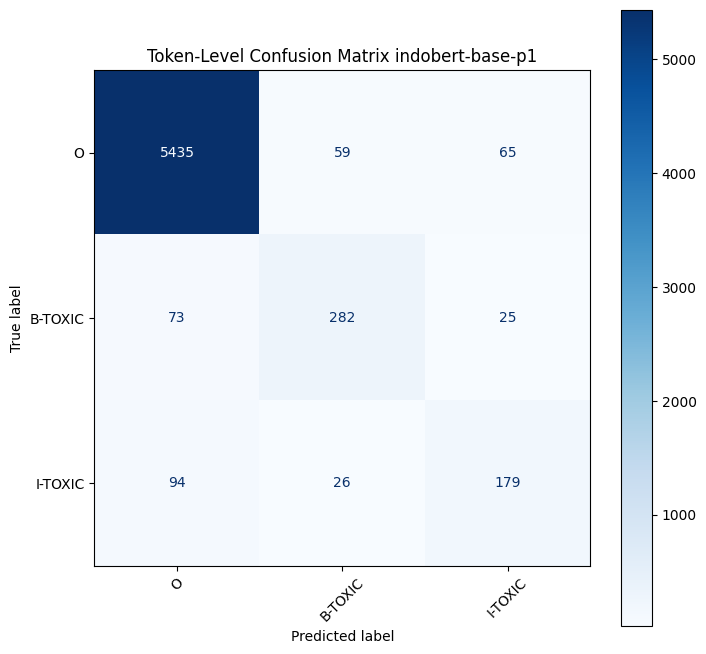

In [36]:
token_confusion_matrix(pred_ids, labels, id2label)

## character f1

### prediction reverse engineering

In [37]:
import numpy as np

def reconstruct_word_labels(pred_ids, word_ids, id2label):

    word_labels = []

    previous_word_id = None

    for pred_id, word_id in zip(pred_ids, word_ids):

        # Skip special tokens
        if word_id == -1:
            continue

        # First subtoken only
        if word_id != previous_word_id:

            word_labels.append(id2label[pred_id])

        previous_word_id = word_id

    return word_labels


In [38]:
def word_labels_to_char_spans(words, word_labels):

    text = " ".join(words)
    spans = []

    current_pos = 0

    for word, label in zip(words, word_labels):

        start = current_pos
        end = start + len(word)

        if label.startswith("B") or label.startswith("I"):
            spans.extend(range(start, end))

        current_pos = end + 1

    return text, spans

In [39]:
pred_char_spans = []
pred_tokens = []
tokens_p = []
sentences_p = []

for pred_seq, sample in zip(pred_ids, tokenized_dataset_test):
  
    word_level_preds = reconstruct_word_labels(
        pred_seq,
        sample["word_ids"],
        id2label
    )
    

    sentence, char_spans = word_labels_to_char_spans(
    sample["tokens"],
    word_level_preds
    )

    pred_char_spans.append(char_spans)
    sentences_p.append(sentence)
    pred_tokens.append(word_level_preds)
    tokens_p.append(sample["tokens"])

In [40]:
predictions_dict = {
    "sentence_p" : sentences_p,
    "token_p" : tokens_p,
    "pred_char_spans" : pred_char_spans,
    "pred_tokens" : pred_tokens
}

In [41]:
gold_char_spans = []
gold_tokens = []
tokens_g = []
sentences_g = []

for i in tokenized_dataset_test:
    char_span = []
    sentence = " ".join(i["tokens"])
    for token, tag in zip(i["tokens"], i["ner_tags"]):
    
        if tag !=0: #if tags not O or 0
            start = sentence.find(token)
            end = start + len(token)
            idx = list(range(start, end))
            char_span.extend(idx)
            
        
    gold_char_spans.append(char_span)
    gold_tokens.append(i["ner_tags"])
    tokens_g.append(i["tokens"])
    sentences_g.append(sentence)

In [42]:
gold_dict = {
    "sentence_g" : sentences_g,
    "token_g" : tokens_g,
    "gold_char_spans" : gold_char_spans,
    "gold_tokens" : gold_tokens
}

In [43]:
def f1(predictions, gold):
    """
    F1 (a.k.a. DICE) operating on two lists of offsets (e.g., character).
    >>> assert f1([0, 1, 4, 5], [0, 1, 6]) == 0.5714285714285714
    :param predictions: a list of predicted offsets
    :param gold: a list of offsets serving as the ground truth
    :return: a score between 0 and 1
    """

    """
    @inproceedings{pavlopoulos-etal-2022-acl,
    title = "From the Detection of Toxic Spans in Online Discussions to the Analysis of Toxic-to-Civil Transfer",
    author = "Pavlopoulos, John  and Laugier, L{\'e}o and Xenos, Alexandros and Sorensen, Jeffrey and Androutsopoulos, Ion",
    booktitle = "Proceedings of the 60th Annual Meeting of the Association for Computational Linguistics (ACL 2022).",
    month = may,
    year = "2022",
    address = "Dublin, Ireland",
    publisher = "Association for Computational Linguistics",
}

@inproceedings{pavlopoulos-etal-2021-semeval,
    title = "{S}em{E}val-2021 Task 5: Toxic Spans Detection",
    author = "Pavlopoulos, John  and Sorensen, Jeffrey  and Laugier, L{\'e}o and Androutsopoulos, Ion",
    booktitle = "Proceedings of the 15th International Workshop on Semantic Evaluation (SemEval-2021)",
    month = aug,
    year = "2021",
    address = "Online",
    publisher = "Association for Computational Linguistics",
    url = "https://aclanthology.org/2021.semeval-1.6",
    doi = "10.18653/v1/2021.semeval-1.6",
    pages = "59--69",
}
    """
    if len(gold) == 0:
        return 1. if len(predictions) == 0 else 0.
    if len(predictions) == 0:
        return 0.
    predictions_set = set(predictions)
    gold_set = set(gold)
    nom = 2 * len(predictions_set.intersection(gold_set))
    denom = len(predictions_set) + len(gold_set)
    return float(nom)/float(denom)

In [44]:
from scipy.stats import sem

scores = []
for gold, prediction in zip(gold_dict["gold_char_spans"], predictions_dict["pred_char_spans"]):
    score = f1(prediction, gold)
    scores.append(score)

char_f1 = float(np.mean(scores))
sem = float(sem(scores))

print(f"char_f1 : {char_f1}\n sem : {sem}")

char_f1 : 0.8238520084244122
 sem : 0.013738021033942519


In [45]:
pred_ids.shape

(538, 166)

# indolem/indobert-base-uncased

## load model

In [46]:
from transformers import BertTokenizer, AutoModel

tokenizer = BertTokenizer.from_pretrained("indolem/indobert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [47]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True, return_offsets_mapping=True)

    labels = []
    #addition
    all_word_ids = []
    for i, label in enumerate(examples[f"ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)  # Map tokens to their respective word.
        previous_word_idx = None
        label_ids = []
        
        for word_idx in word_ids:  # Set the special tokens to -100.
            if word_idx is None:
                label_ids.append(-100)
                
            elif word_idx != previous_word_idx:  # Only label the first token of a given word.
                label_ids.append(label[word_idx])
                
            else:
                label_ids.append(-100)
                
            previous_word_idx = word_idx
            
        labels.append(label_ids)
        
        # SAVE word_ids (addition)
        all_word_ids.append([
            -1 if w is None else w
            for w in word_ids
        ])
        
    tokenized_inputs["word_ids"] = all_word_ids
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

In [48]:
tokenized_dataset_train = train_dataset.map(tokenize_and_align_labels, batched=True)
tokenized_dataset_val = val_dataset.map(tokenize_and_align_labels, batched=True)
tokenized_dataset_test = test_dataset.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/4308 [00:00<?, ? examples/s]

Map:   0%|          | 0/539 [00:00<?, ? examples/s]

Map:   0%|          | 0/538 [00:00<?, ? examples/s]

In [49]:
tokenized_dataset_train

Dataset({
    features: ['tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'word_ids', 'labels'],
    num_rows: 4308
})

In [50]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

## evaluate

In [51]:
import evaluate

seqeval = evaluate.load("seqeval")

In [52]:
import numpy as np


def compute_metrics_seqeval(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"]
    }

In [53]:
def compute_all_metrics(p):
    results = {}
    results.update(compute_metrics_seqeval(p))

    return results

## model loading and training

In [54]:
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer, EarlyStoppingCallback

model = AutoModelForTokenClassification.from_pretrained(
    "indolem/indobert-base-uncased", num_labels=3, id2label=id2label, label2id=label2id
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly in

In [55]:
training_args = TrainingArguments(
    output_dir="/kaggle/working/indobert-base-uncased_toxic_span",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps= 10,

)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset_train,
    eval_dataset=tokenized_dataset_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_all_metrics,
)

trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.460317,0.462114,0.415217,0.521858,0.462470
2,0.500620,0.387473,0.495050,0.546448,0.519481


Error during conversion: AttributeError("'str' object has no attribute 'decode'")


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=270, training_loss=0.5757134508203577, metrics={'train_runtime': 92.7881, 'train_samples_per_second': 92.857, 'train_steps_per_second': 2.91, 'total_flos': 331843757063976.0, 'train_loss': 0.5757134508203577, 'epoch': 2.0})

## logging loss

In [56]:
logs = trainer.state.log_history

In [57]:
train_logs = [x for x in logs if "loss" in x and "eval_loss" not in x]

In [58]:
eval_logs = [x for x in logs if "eval_loss" in x]

In [59]:
for log in train_logs:
    print(log["epoch"], log["loss"])

0.07407407407407407 1.1828662872314453
0.14814814814814814 0.8227643966674805
0.2222222222222222 0.7263661384582519
0.2962962962962963 0.7243594646453857
0.37037037037037035 0.7180789947509766
0.4444444444444444 0.7467211723327637
0.5185185185185185 0.6355083465576172
0.5925925925925926 0.5630589485168457
0.6666666666666666 0.6659282207489013
0.7407407407407407 0.5546872615814209
0.8148148148148148 0.519047737121582
0.8888888888888888 0.572781753540039
0.9629629629629629 0.4603170394897461
1.037037037037037 0.47576541900634767
1.1111111111111112 0.5027829647064209
1.1851851851851851 0.5135139465332031
1.2592592592592593 0.5461347579956055
1.3333333333333333 0.5116660118103027
1.4074074074074074 0.48383255004882814
1.4814814814814814 0.4942764759063721
1.5555555555555556 0.4510976314544678
1.6296296296296298 0.39761919975280763
1.7037037037037037 0.40331344604492186
1.7777777777777777 0.5279860496520996
1.8518518518518519 0.4125341892242432
1.925925925925926 0.4306344032287598
2.0 0.500

In [60]:
for log in eval_logs:
    print(log["epoch"], log["eval_loss"])

1.0 0.4621138274669647
2.0 0.38747262954711914


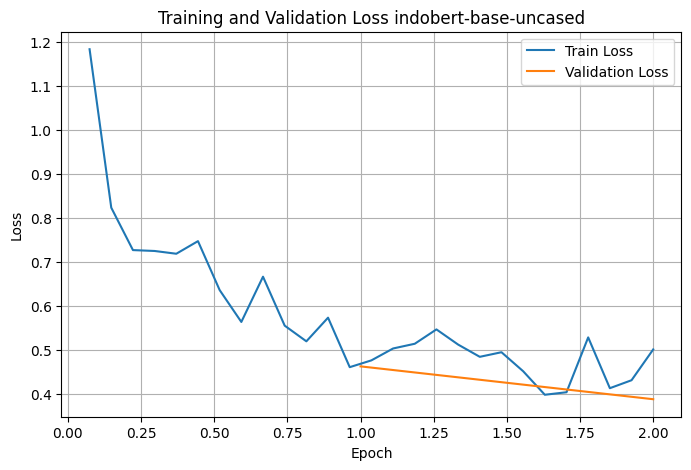

In [61]:
import matplotlib.pyplot as plt

train_epochs = [x["epoch"] for x in train_logs] # Epochs/step logs
train_loss = [x["loss"] for x in train_logs]

eval_epochs = [x["epoch"] for x in eval_logs]
eval_loss = [x["eval_loss"] for x in eval_logs]

# Plot
plt.figure(figsize=(8,5))

plt.plot(train_epochs, train_loss, label="Train Loss")
plt.plot(eval_epochs, eval_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss indobert-base-uncased")

plt.legend()
plt.grid(True)

plt.show()

## Testing

In [62]:
SAVE_PATH = "/kaggle/working/indobert-base_uncased_toxic_span"
trainer.save_model(SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [63]:
tokenized_dataset_test[0]

{'tokens': ['bencong', 'rombengmenjijikangay', 'jg'],
 'ner_tags': [1, 2, 0],
 'input_ids': [3,
  1828,
  22331,
  2977,
  14058,
  28271,
  1478,
  4190,
  11028,
  1534,
  950,
  23599,
  4],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'offset_mapping': [[0, 0],
  [0, 3],
  [3, 7],
  [0, 3],
  [3, 6],
  [6, 8],
  [8, 10],
  [10, 12],
  [12, 17],
  [17, 19],
  [19, 20],
  [0, 2],
  [0, 0]],
 'word_ids': [-1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, -1],
 'labels': [-100,
  1,
  -100,
  2,
  -100,
  -100,
  -100,
  -100,
  -100,
  -100,
  -100,
  0,
  -100]}

In [64]:
output = trainer.predict(tokenized_dataset_test)

predictions = output.predictions
labels = output.label_ids
pred_ids = np.argmax(predictions, axis=2)


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [65]:
output.metrics

{'test_loss': 0.42513900995254517,
 'test_precision': 0.463768115942029,
 'test_recall': 0.5052631578947369,
 'test_f1': 0.4836272040302267,
 'test_runtime': 2.1792,
 'test_samples_per_second': 246.875,
 'test_steps_per_second': 7.801}

In [66]:
predictions.shape

(538, 164, 3)

### token level analysis

In [67]:
from sklearn.metrics import classification_report

def token_analysis(pred_ids, labels, id2label):
    y_true = []
    y_pred = []

    for pred_seq, gold_seq in zip(pred_ids, labels):
        for p, g in zip(pred_seq, gold_seq):
            if g == -100:
                continue  # ignore subwords

            y_true.append(id2label[g])
            y_pred.append(id2label[p])

    print(classification_report(y_true, y_pred, digits=4))

In [68]:
token_analysis(pred_ids, labels, id2label)

              precision    recall  f1-score   support

     B-TOXIC     0.6516    0.6053    0.6276       380
     I-TOXIC     0.5679    0.5318    0.5492       299
           O     0.9615    0.9694    0.9654      5559

    accuracy                         0.9263      6238
   macro avg     0.7270    0.7022    0.7141      6238
weighted avg     0.9237    0.9263    0.9249      6238



In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def token_confusion_matrix(pred_ids, labels, id2label):

    y_true = []
    y_pred = []

    # Flatten predictions
    for pred_seq, gold_seq in zip(pred_ids, labels):

        for p, g in zip(pred_seq, gold_seq):

            # ignore subwords
            if g == -100:
                continue

            y_true.append(id2label[g])
            y_pred.append(id2label[p])

    # Label order
    label_names = list(id2label.values())

    # Create confusion matrix
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=label_names
    )

    # Plot
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_names
    )

    fig, ax = plt.subplots(figsize=(8,8))
    disp.plot(ax=ax, cmap="Blues")

    plt.xticks(rotation=45)
    plt.title("Token-Level Confusion Matrix indobert-base-uncased")
    plt.show()

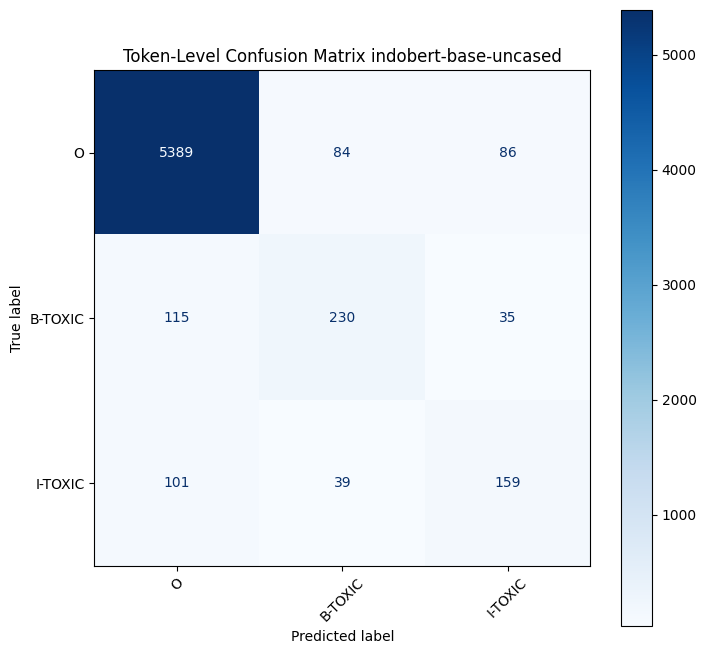

In [70]:
token_confusion_matrix(pred_ids, labels, id2label)

## character f1

### prediction reverse engineering

In [71]:
import numpy as np

def reconstruct_word_labels(pred_ids, word_ids, id2label):

    word_labels = []

    previous_word_id = None

    for pred_id, word_id in zip(pred_ids, word_ids):

        # Skip special tokens
        if word_id == -1:
            continue

        # First subtoken only
        if word_id != previous_word_id:

            word_labels.append(id2label[pred_id])

        previous_word_id = word_id

    return word_labels


In [72]:
def word_labels_to_char_spans(words, word_labels):

    text = " ".join(words)
    spans = []

    current_pos = 0

    for word, label in zip(words, word_labels):

        start = current_pos
        end = start + len(word)

        if label.startswith("B") or label.startswith("I"):
            spans.extend(range(start, end))

        current_pos = end + 1

    return text, spans

In [73]:
pred_char_spans = []
pred_tokens = []
tokens_p = []
sentences_p = []

for pred_seq, sample in zip(pred_ids, tokenized_dataset_test):
  
    word_level_preds = reconstruct_word_labels(
        pred_seq,
        sample["word_ids"],
        id2label
    )
    

    sentence, char_spans = word_labels_to_char_spans(
    sample["tokens"],
    word_level_preds
    )

    pred_char_spans.append(char_spans)
    sentences_p.append(sentence)
    pred_tokens.append(word_level_preds)
    tokens_p.append(sample["tokens"])

In [74]:
predictions_dict = {
    "sentence_p" : sentences_p,
    "token_p" : tokens_p,
    "pred_char_spans" : pred_char_spans,
    "pred_tokens" : pred_tokens
}

In [75]:
gold_char_spans = []
gold_tokens = []
tokens_g = []
sentences_g = []

for i in tokenized_dataset_test:
    char_span = []
    sentence = " ".join(i["tokens"])
    for token, tag in zip(i["tokens"], i["ner_tags"]):
    
        if tag !=0: #if tags not O or 0
            start = sentence.find(token)
            end = start + len(token)
            idx = list(range(start, end))
            char_span.extend(idx)
            
        
    gold_char_spans.append(char_span)
    gold_tokens.append(i["ner_tags"])
    tokens_g.append(i["tokens"])
    sentences_g.append(sentence)

In [76]:
gold_dict = {
    "sentence_g" : sentences_g,
    "token_g" : tokens_g,
    "gold_char_spans" : gold_char_spans,
    "gold_tokens" : gold_tokens
}

In [77]:
def f1(predictions, gold):
    """
    F1 (a.k.a. DICE) operating on two lists of offsets (e.g., character).
    >>> assert f1([0, 1, 4, 5], [0, 1, 6]) == 0.5714285714285714
    :param predictions: a list of predicted offsets
    :param gold: a list of offsets serving as the ground truth
    :return: a score between 0 and 1
    """

    """
    @inproceedings{pavlopoulos-etal-2022-acl,
    title = "From the Detection of Toxic Spans in Online Discussions to the Analysis of Toxic-to-Civil Transfer",
    author = "Pavlopoulos, John  and Laugier, L{\'e}o and Xenos, Alexandros and Sorensen, Jeffrey and Androutsopoulos, Ion",
    booktitle = "Proceedings of the 60th Annual Meeting of the Association for Computational Linguistics (ACL 2022).",
    month = may,
    year = "2022",
    address = "Dublin, Ireland",
    publisher = "Association for Computational Linguistics",
}

@inproceedings{pavlopoulos-etal-2021-semeval,
    title = "{S}em{E}val-2021 Task 5: Toxic Spans Detection",
    author = "Pavlopoulos, John  and Sorensen, Jeffrey  and Laugier, L{\'e}o and Androutsopoulos, Ion",
    booktitle = "Proceedings of the 15th International Workshop on Semantic Evaluation (SemEval-2021)",
    month = aug,
    year = "2021",
    address = "Online",
    publisher = "Association for Computational Linguistics",
    url = "https://aclanthology.org/2021.semeval-1.6",
    doi = "10.18653/v1/2021.semeval-1.6",
    pages = "59--69",
}
    """
    if len(gold) == 0:
        return 1. if len(predictions) == 0 else 0.
    if len(predictions) == 0:
        return 0.
        
    predictions_set = set(predictions)
    gold_set = set(gold)
    nom = 2 * len(predictions_set.intersection(gold_set))
    denom = len(predictions_set) + len(gold_set)
    return float(nom)/float(denom)

In [78]:
from scipy.stats import sem

scores = []
for gold, prediction in zip(gold_dict["gold_char_spans"], predictions_dict["pred_char_spans"]):
    score = f1(prediction, gold)
    scores.append(score)

char_f1 = float(np.mean(scores))
sem = float(sem(scores))

print(f"char_f1 : {char_f1}\n sem : {sem}")

char_f1 : 0.7424396206493866
 sem : 0.016280070352270293


In [79]:
pred_ids.shape

(538, 164)